In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [3]:
# To ensure reproducible results
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
file_path = '/content/drive/MyDrive/DF_2026_Demo/dataset_sample.csv'
df = pd.read_csv(file_path)
print("Data preview:")
print(df.head())

Data preview:
          X1         X2         X3         X4          X5           X6   Y1
0  34.400423  13.208689   7.643646  13.251368  117.996835  -299.610602  460
1  35.960094   10.05798  17.976625   8.107629  121.996835  -299.610602  440
2   32.14675   7.736695   24.90996   3.678209  125.996835  -299.610602  400
3  28.384832   7.109847  33.460369  11.430173  129.996835  -299.610602  350
4  24.697851   8.558236  32.951069  16.608829  133.996835  -299.610602  300


In [5]:
# Convert all columns to numeric (non-convertible values become NaN)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN and reset the index
df = df.dropna().reset_index(drop=True)

data = df.values
X = df[["X1","X2", "X3","X4","X5","X6"]].values # Changed this line to use .values after selecting the dataframe columns.
y = df["Y1"].values # Changed this line to use .values

In [6]:
# Single train/test split.
# Keep the RAW (unscaled) copies — we need them later for ONNX export and golden cases.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train/test split:", X_train_raw.shape, X_test_raw.shape)

Train/test split: (5032, 6) (1258, 6)


In [7]:
# Fit ONE StandardScaler on the TRAINING data only, then reuse it for the test set.
# (Fitting a second time, or fitting on already-scaled data, silently corrupts the model.)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("\nShapes of training and testing sets:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Shapes of training and testing sets:
X_train shape: (5032, 6)
y_train shape: (5032,)
X_test shape: (1258, 6)
y_test shape: (1258,)


In [8]:
# NOTE: scaling is already complete above (one scaler, fit on the training set only).
# An earlier draft re-ran fit_transform here, which double-applied StandardScaler
# and trained the model on corrupted data. That redundant step has been removed.

In [9]:
# Build an updated ANN model with L2 regularization, BatchNormalization, and Dropout
model = keras.Sequential([
    layers.Dense(
        256, activation='relu',
        input_shape=(X_train.shape[1],),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1)  # Output layer for regression
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Use Adam optimizer with a learning rate of 0.001
optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Compile the model, using MSE as the loss function and MAE as a metric
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

In [11]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 135946.9375 - mae: 328.0188 - val_loss: 134850.6406 - val_mae: 323.4886 - learning_rate: 0.0010
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 127470.4297 - mae: 320.5045 - val_loss: 129786.9062 - val_mae: 321.7087 - learning_rate: 0.0010
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 114998.7344 - mae: 305.4329 - val_loss: 119110.8984 - val_mae: 312.0605 - learning_rate: 0.0010
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 100061.7031 - mae: 283.7261 - val_loss: 100958.0781 - val_mae: 287.0406 - learning_rate: 0.0010
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 83763.2812 - mae: 256.7481 - val_loss: 78595.9375 - val_mae: 249.7449 - learning_rate: 0.0010
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 67203.9609 - mae: 225.2897 - val_loss: 61636.6523 - val_mae: 217.1409 - learning_rate: 0.0010
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5

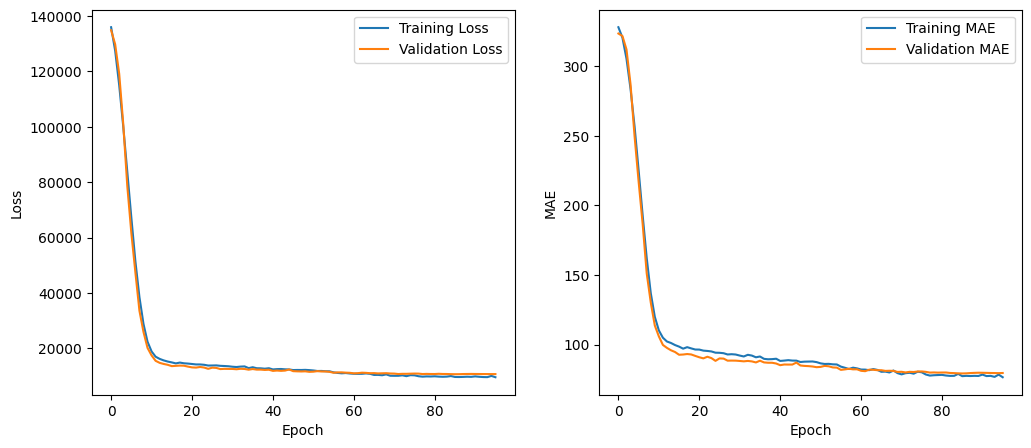

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10909.6104 - mae: 80.8500
Test set Loss: 10909.6103515625
Test set MAE: 80.85001373291016
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training set R²: 0.7132250048260608
Test set R²: 0.64880297281785


In [12]:
# Train (using 20% of the training data for validation)
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr]
)

# Plot training curves for loss and MAE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

# Evaluate on test set
loss, mae = model.evaluate(X_test, y_test)
print("Test set Loss:", loss)
print("Test set MAE:", mae)

y_train_pred = model.predict(X_train).ravel()
y_test_pred = model.predict(X_test).ravel()

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Training set R²:", r2_train)
print("Test set R²:", r2_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


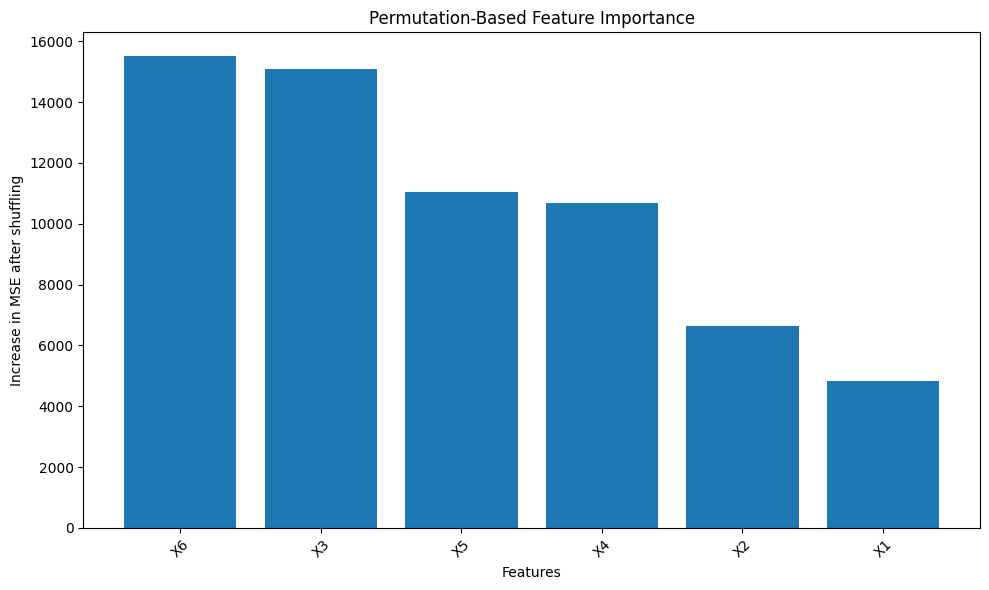

In [13]:
# Permutation-based feature importance
# ------------------------------------
# 1. Compute baseline error (MSE) on the test set
baseline_mse = mean_squared_error(y_test, y_test_pred)

# Define feature names (replace with your actual feature names)
feature_names = ["X1", "X2", "X3", "X4", "X5", "X6"]  # Assuming these are your feature names

# 2. For each feature, shuffle its values in the test set and measure change in error
importances = []
X_test_copy = np.copy(X_test)
for i in range(X_test.shape[1]):
    # Save the column
    save_col = np.copy(X_test_copy[:, i])

    # Shuffle the feature
    np.random.shuffle(X_test_copy[:, i])

    # Predict on the shuffled data
    y_test_shuffled_pred = model.predict(X_test_copy).ravel()

    # Compute new MSE
    mse_shuffled = mean_squared_error(y_test, y_test_shuffled_pred)

    # Restore original feature values for next iteration
    X_test_copy[:, i] = save_col

    # Importance is the difference between new MSE and baseline MSE
    importances.append(mse_shuffled - baseline_mse)

# Convert to a NumPy array
importances = np.array(importances)

# Sort features by importance
indices = np.argsort(importances)[::-1]  # largest to smallest
sorted_importances = importances[indices]

# Convert indices to a list to use for indexing the feature_names list
indices_list = indices.tolist()

# Use indices_list to index feature_names
sorted_names = [feature_names[i] for i in indices_list] # Changed this line to use list comprehension for indexing

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances)
plt.xticks(range(len(sorted_importances)), sorted_names, rotation=45)
plt.xlabel("Features")
plt.ylabel("Increase in MSE after shuffling")
plt.title("Permutation-Based Feature Importance")
plt.tight_layout()
plt.show()

## Encapsulation: export a deployable ONNX package

A trained model is not yet a usable tool. Below we turn it into an **inference module with a clear contract**:

1. **Bake the scaler into the graph** — the ONNX model takes RAW inputs, so downstream (Grasshopper / web) never has to reproduce `StandardScaler`. This is the same raw-input contract as the Random Forest model.
2. **Validate** native vs. ONNX Runtime predictions with a tolerance.
3. **Ship the contract** — a manifest with feature order, dtype, training range, SHA-256 checksum, and golden cases.

In [14]:
# Install the Keras -> ONNX converter and the runtime used to validate the export
!pip install -q tf2onnx onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 51.1 MB/s eta 0:00:00


In [15]:
import os, json, hashlib
import tf2onnx
import onnx
from tensorflow.keras import layers

# --- Bake the StandardScaler INTO the graph so the ONNX model takes RAW inputs ---
# StandardScaler does (x - mean_) / sqrt(var_); keras Normalization does exactly the same,
# so we initialise a Normalization layer directly from the fitted scaler.
norm = layers.Normalization(axis=-1, mean=scaler.mean_, variance=scaler.var_)

raw_input = keras.Input(shape=(6,), name="float_input", dtype="float32")
scaled    = norm(raw_input)
output    = model(scaled)                       # reuse the already-trained network
inference_model = keras.Model(raw_input, output, name="ann_inference")

# Convert to ONNX. Input = RAW, unscaled 6 features (same contract as rf_model.onnx).
dataset_dir = os.path.dirname(file_path)
onnx_path   = os.path.join(dataset_dir, "ann_model.onnx")

spec = (tf.TensorSpec((None, 6), tf.float32, name="float_input"),)
onnx_model, _ = tf2onnx.convert.from_keras(
    inference_model, input_signature=spec, opset=13, output_path=onnx_path
)
print("ONNX model saved to:", onnx_path)

ONNX model saved to: /content/drive/MyDrive/DF_2026_Demo/ann_model.onnx


In [16]:
# --- Validate: native Keras vs ONNX Runtime (don't eyeball a few numbers) ---
import onnxruntime as ort

n_gold    = 5
X_gold_raw = X_test_raw[:n_gold].astype(np.float32)   # RAW inputs, as GH would send

# Native path: raw -> scaler -> keras model
native_pred = model.predict(scaler.transform(X_gold_raw)).ravel()

# ONNX path: raw -> onnx (scaler lives inside the graph)
sess    = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
onnx_pred = sess.run(None, {in_name: X_gold_raw})[0].ravel()

print("native:", np.round(native_pred, 4))
print("onnx:  ", np.round(onnx_pred, 4))
max_abs_diff = float(np.max(np.abs(native_pred - onnx_pred)))
print("max |native - onnx| =", max_abs_diff)
assert max_abs_diff < 1e-2, "ONNX export does NOT match the trained model!"
print("✅ ONNX matches the native model within tolerance.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
native: [105.2599 273.167  162.2498 615.8554 407.8899]
onnx:   [105.2599 273.1672 162.2498 615.8556 407.89  ]
max |native - onnx| = 0.0001220703125
✅ ONNX matches the native model within tolerance.


In [17]:
# --- Ship the CONTRACT, not just the file: manifest + golden cases + checksum ---
feature_names = ["X1", "X2", "X3", "X4", "X5", "X6"]
X_all_raw = df[feature_names].values

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

golden_cases = [
    {"input": X_gold_raw[i].tolist(), "expected": float(onnx_pred[i]), "tolerance": 1e-2}
    for i in range(n_gold)
]

manifest = {
    "name": "ann_surrogate",
    "version": "1.0.0",
    "framework": "tensorflow-keras -> onnx (tf2onnx)",
    "onnx_opset": 13,
    "model_file": os.path.basename(onnx_path),
    "sha256": sha256(onnx_path),
    "input": {
        "name": in_name,
        "dtype": "float32",
        "shape": [None, 6],
        "feature_order": feature_names,
        "preprocessing": "StandardScaler baked into the graph -> send RAW values",
        "training_range": {
            n: [float(X_all_raw[:, i].min()), float(X_all_raw[:, i].max())]
            for i, n in enumerate(feature_names)
        },
    },
    "output": {"name": sess.get_outputs()[0].name, "meaning": "Y1 (regression target)"},
    "golden_cases": golden_cases,
}

manifest_path = os.path.join(dataset_dir, "ann_model_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print("Manifest saved to:", manifest_path)
print(json.dumps(manifest, indent=2))

Manifest saved to: /content/drive/MyDrive/DF_2026_Demo/ann_model_manifest.json
{
  "name": "ann_surrogate",
  "version": "1.0.0",
  "framework": "tensorflow-keras -> onnx (tf2onnx)",
  "onnx_opset": 13,
  "model_file": "ann_model.onnx",
  "sha256": "e510e210971b002fc2106630041a48c9607c69e49bc77429ac5cc5f9a899fa87",
  "input": {
    "name": "float_input",
    "dtype": "float32",
    "shape": [
      null,
      6
    ],
    "feature_order": [
      "X1",
      "X2",
      "X3",
      "X4",
      "X5",
      "X6"
    ],
    "preprocessing": "StandardScaler baked into the graph -> send RAW values",
    "training_range": {
      "X1": [
        6.981573,
        59.863156
      ],
      "X2": [
        1.485979,
        80.370284
      ],
      "X3": [
        0.0,
        66.53256
      ],
      "X4": [
        0.0,
        49.839784
      ],
      "X5": [
        -38.003165,
        197.996835
      ],
      "X6": [
        -299.610602,
        -111.610602
      ]
    }
  },
  "output": 